<a href="https://colab.research.google.com/github/shalinitiwari5033/Autonomous_Research_Paper_Summarizer/blob/main/Airbnb_Hotel_Booking_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [12]:
df=pd.read_excel("/content/Airbnb_Open_Data.xlsx")

In [13]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

#####neighbourhood group was "brookln" instead of "brooklyn"

In [15]:
df[df["neighbourhood group"]=="brookln"]

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",26802410424,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,116.0,4.0,167.0,2019-06-24,1.34,4.0,3.0,47.0,NaN,NaN


In [16]:
df.duplicated().value_counts()

,count
False,102058
True,541


In [17]:
df.drop_duplicates(inplace=True)
df.drop(["house_rules","license"],axis=1,inplace=True)

In [60]:
# remove all doller sign
df["price"]=df["price"].str.reeplace("$","",regex=False)
df["service fee"]=df["service fe"].str.replace("$","",regex=False)

In [57]:
# remove all commas
df["price"]=df["price"].str.replace(",","",regex=False)
df["service fee"]=df["service fee"].str.replace(",","",regex=False)

In [39]:
# rename the price and services fee columns to include a doller sign
df.rename(columns={
    "price":"price_$",
    "service fee":"service_fee_$"
},inplace=True)
df.dropna(inplace=True)
# convert the price and services fee columns to float
df["price_$"]=df["price_$"].astype(float)
df["service_fee_$"]=df["service_fee_$"].astype(float)
df["id"]=df["id"].astype(int)
df["host id"]=df["host id"].astype(int)


In [55]:
df["last review"]=df.to_datetime(df["last review"])
df['Construction year']=df["Construction year"].astype(int)

In [23]:
df.loc[df["neighbourhood group"]=="brookln","neighbourhood group"]="Brooklyn"
df=df.drop(df[df["availability 365"]>500].index)

In [24]:
df.duplicated().value_counts()


,count
False,83389


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83389 entries, 0 to 102040
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              83389 non-null  int64         
 1   NAME                            83389 non-null  object        
 2   host id                         83389 non-null  int64         
 3   host_identity_verified          83389 non-null  object        
 4   host name                       83389 non-null  object        
 5   neighbourhood group             83389 non-null  object        
 6   neighbourhood                   83389 non-null  object        
 7   lat                             83389 non-null  float64       
 8   long                            83389 non-null  float64       
 9   country                         83389 non-null  object        
 10  country code                    83389 non-null  object        
 11  instan

##EDA

In [26]:
df.describe()

,id,host id,lat,long,instant_bookable,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,8.338900e+04,8.338900e+04,83389.000000,83389.000000,83389.000000,83389.000000,83389.000000,83389.000000,83389.000000,83389.000000,83389,83389.000000,83389.000000,83389.000000,83389.000000
mean,2.957590e+07,4.918226e+10,40.727349,-73.948502,0.497704,2012.487810,626.209668,125.243114,7.406109,32.261305,2019-06-08 21:32:53.396971008,1.377352,3.278694,7.032894,141.746369
min,1.001254e+06,1.236005e+08,40.504560,-74.249840,0.000000,2003.000000,50.000000,10.000000,-365.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,1.541637e+07,2.444702e+10,40.687640,-73.982110,0.000000,2007.000000,340.000000,68.000000,2.000000,3.000000,2018-10-25 00:00:00,0.220000,2.000000,1.000000,6.000000
50%,3.075760e+07,4.902253e+10,40.721320,-73.953710,0.000000,2012.000000,625.000000,125.000000,3.000000,11.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,101.000000
75%,4.331856e+07,7.384793e+10,40.762600,-73.930800,1.000000,2017.000000,914.000000,183.000000,5.000000,38.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,266.000000
max,5.735803e+07,9.876313e+10,40.916970,-73.705220,1.000000,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,426.000000
std,1.621857e+07,2.853548e+10,0.056326,0.050342,0.499998,5.760526,331.803443,66.364212,28.105563,51.954290,NaN,1.751091,1.283678,29.555458,133.377544


####what are the diffrent property types in the datasets

In [27]:
property_types=df["room type"].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,44161
Private room,37474
Shared room,1646
Hotel room,108


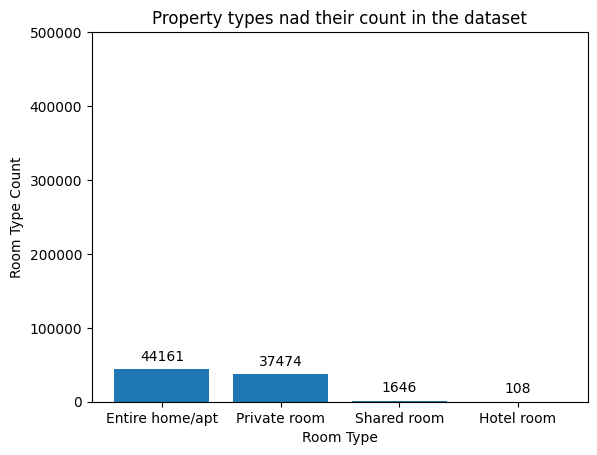

In [28]:
# room type count plotted on a barchart
room_type_bar=plt.bar(property_types.index,property_types.loc[:,"count"]);
plt.bar_label(room_type_bar,labels=property_types.loc[:,"count"],padding=4 );
plt.ylim(0,500000)
plt.title("Property types nad their count in the dataset");
plt.xlabel("Room Type");
plt.ylabel("Room Type Count");

####Which neighbourhood  group has highest number of listings

In [29]:
hood_group=df["neighbourhood group"].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Brooklyn,34622
Manhattan,34560
Queens,11124
Bronx,2267
Staten Island,816


which Neighbourhood group has the highest number of listing ?


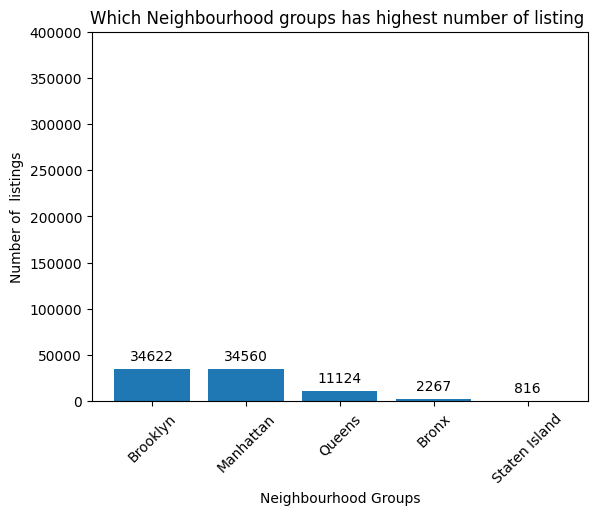

In [30]:
hood_group_bar=plt.bar(hood_group.index,hood_group.loc[:,"count"]);
plt.bar_label(hood_group_bar,labels=hood_group.loc[:,"count"],padding=4 );
plt.ylim(0,400000)
plt.xlabel("Neighbourhood Groups");
plt.ylabel("Number of  listings");
plt.xticks(rotation=45);
plt.title("Which Neighbourhood groups has highest number of listing ");

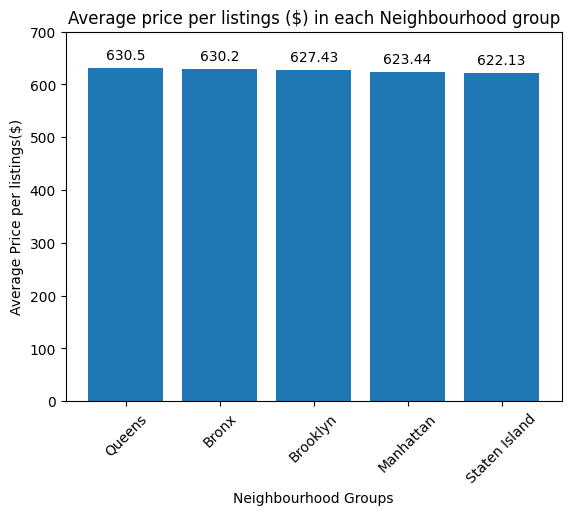

In [31]:
# which neighbouhood grp have the highest average prices for airbnb listings
avg_price=df.groupby("neighbourhood group")["price_$"].mean().sort_values(ascending=False).to_frame()
avg_price_bar=plt.bar(avg_price.index,avg_price.loc[:,"price_$"]);
plt.bar_label(avg_price_bar,labels=round(avg_price.loc[:,"price_$"],2),label_type="edge",padding=4 );
plt.ylim([0,700]);
plt.xlabel("Neighbourhood Groups");
plt.ylabel("Average Price per listings($)");
plt.xticks(rotation=45);
plt.title("Average price per listings ($) in each Neighbourhood group");

is there a relationship between the construction year of property and price


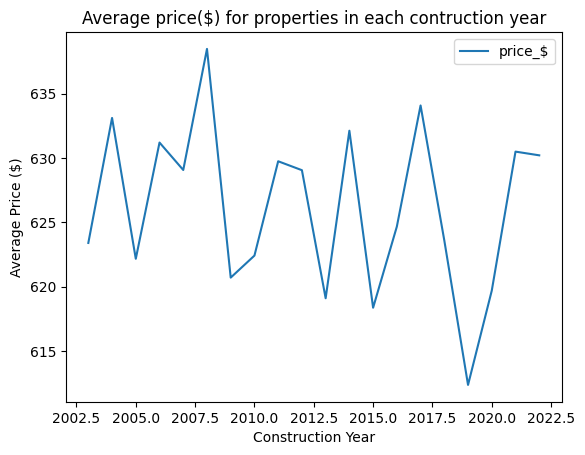

In [32]:
df.groupby("Construction year")["price_$"].mean().to_frame().plot()
plt.xlabel("Construction Year");
plt.ylabel("Average Price ($)");
plt.title("Average price($) for properties in each contruction year");

####whoc the top 10 hosts by calculated host listing count?

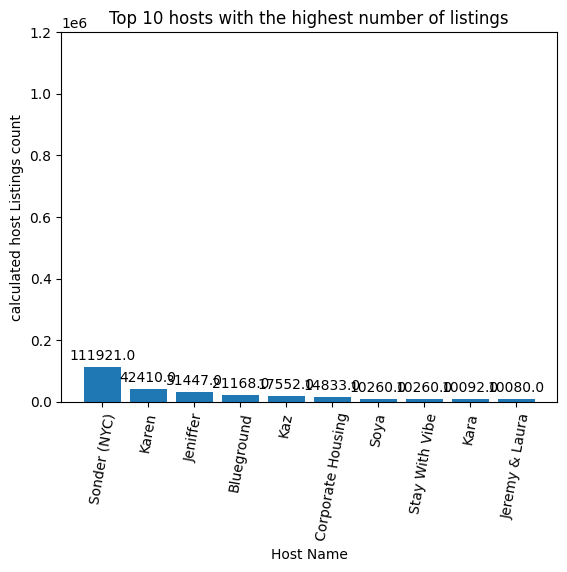

In [54]:
hosts=df.groupby("host name")["calculated host listings count"].sum().sort_values(ascending=False).nlargest(10).to_frame()
hosts_bar=plt.bar(hosts.index,hosts.loc[:,"calculated host listings count"]);
plt.bar_label(hosts_bar,labels=hosts.loc[:,"calculated host listings count"],label_type="edge",padding=3 );
plt.xlabel("Host Name");
plt.ylabel("calculated host Listings count");
plt.xticks(rotation=80);
plt.ylim([0,1200000]);
plt.title("Top 10 hosts with the highest number of listings");


####Are host with verified identities more likely to recieve positive reviews?

In [34]:
review=df.groupby("host_identity_verified")["review rate number"].mean().sort_values(ascending=False).to_frame()
review

,review rate number
host_identity_verified,
verified,3.284066
unconfirmed,3.273325


Text(0.5, 1.0, 'Average review rate for each host verification statistics')

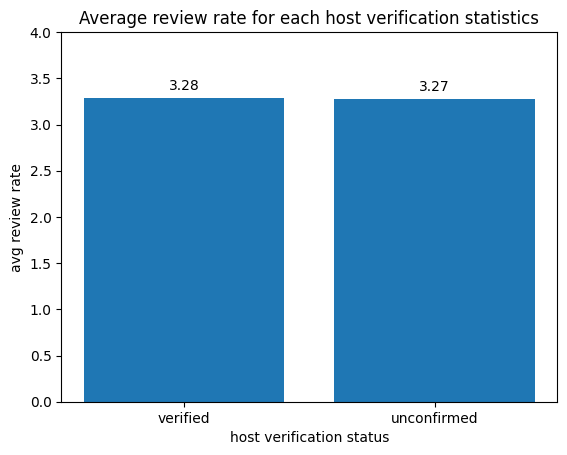

In [41]:
review_bar=plt.bar(review.index,review.loc[:,"review rate number"]);
plt.bar_label(review_bar,labels=round(review.loc[:,"review rate number"],2),padding=4);
plt.ylim([0,4]);
plt.xlabel("host verification status")
plt.ylabel("avg review rate")
plt.title("Average review rate for each host verification statistics")


Text(0.5, 1.0, 'Average Review Rate for each Verification Status ')

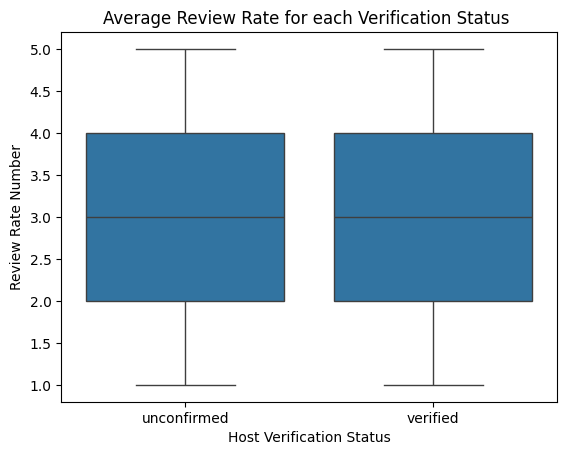

In [42]:
base_color=sns.color_palette()[0]
sns.boxplot(data=df,x="host_identity_verified",y="review rate number",color=base_color);
plt.xlabel("Host Verification Status");
plt.ylabel("Review Rate Number");
plt.title("Average Review Rate for each Verification Status ")

####is there a correlation between the price of a listing and its service fee?

In [45]:
df["price_$"].corr(df["service_fee_$"])

np.float64(0.9999909082976466)

Text(0.5, 1.0, 'A Regression plot showing the corelation of the price')

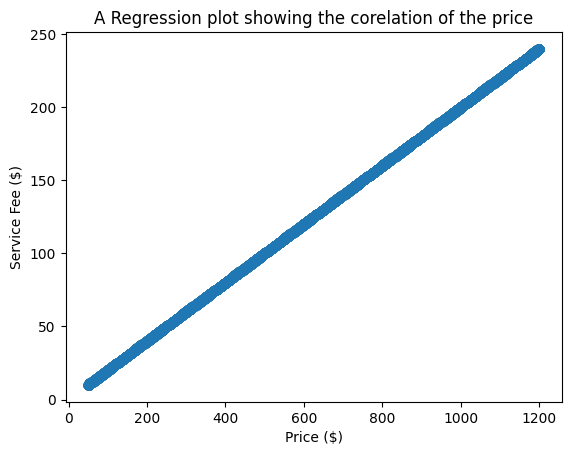

In [46]:
sns.regplot(df,x="price_$",y="service_fee_$");
plt.xlabel("Price ($)");
plt.ylabel("Service Fee ($)");
plt.title("A Regression plot showing the corelation of the price")

###what is the average review rate number (stars) for listings ,does and it vary based on the neighbourhood group and room type ?

In [47]:
ARRN=df.groupby(["neighbourhood group","room type"])["review rate number"].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            3.381881
                    Private room               3.305810
                    Shared room                3.356322
Brooklyn            Entire home/apt            3.242491
                    Hotel room                 3.833333
                    Private room               3.274773
                    Shared room                3.323383
Manhattan           Entire home/apt            3.268846
                    Hotel room                 3.500000
                    Private room               3.285431
                    Shared room                3.261976
Queens              Entire home/apt            3.349528
                    Hotel room                 3.750000
                    Private room               3.310847
                    Shared room                3.327402
Staten Island       Entire home/apt            3.333333
                    Private room               3.497449
                    Shared room                3.714286

Text(0.5, 1.0, 'Average Review Rate Number for each Room/Property for each Neighbourhood Group ')

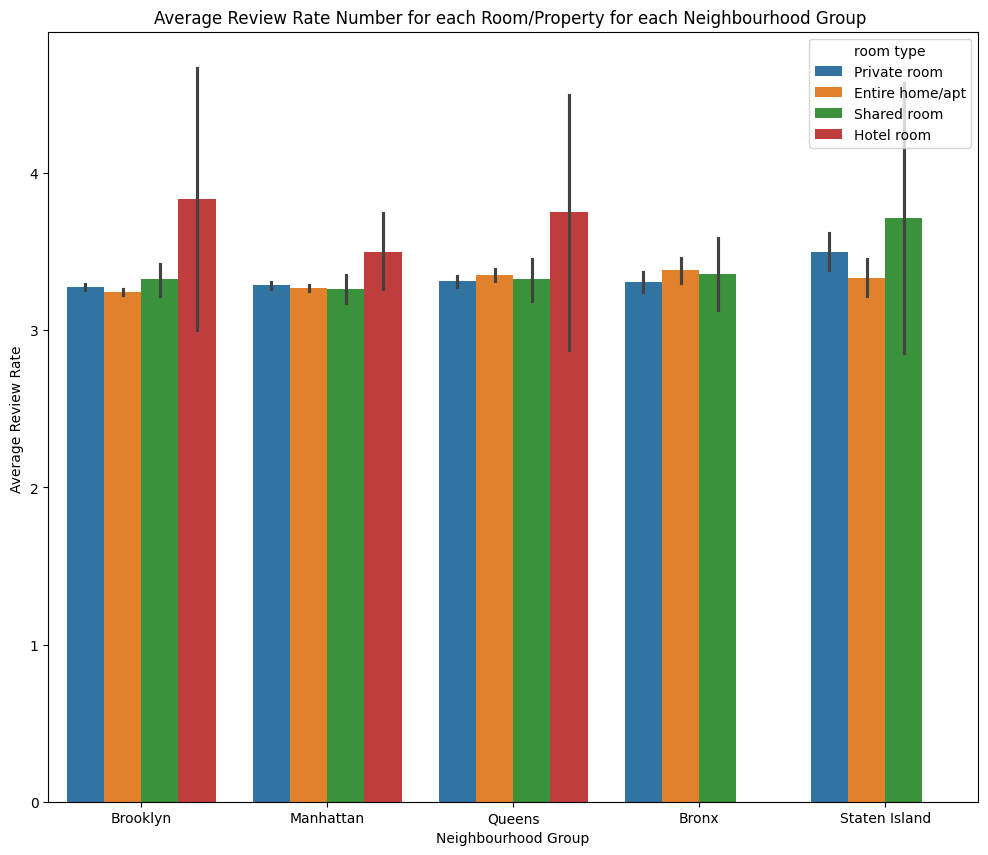

In [50]:
plt.figure(figsize=[12,10]);
sns.barplot(data=df,x="neighbourhood group",y="review rate number",hue="room type");
plt.xlabel("Neighbourhood Group");
plt.ylabel("Average Review Rate ");
plt.title("Average Review Rate Number for each Room/Property for each Neighbourhood Group ")


####Are host  with a higher  calculated host listing countmore likely to maintain higher availability throughout the year ?

Text(0.5, 1.0, 'A regression plot of the relationship between calculated host listings count and availabilty 365 ')

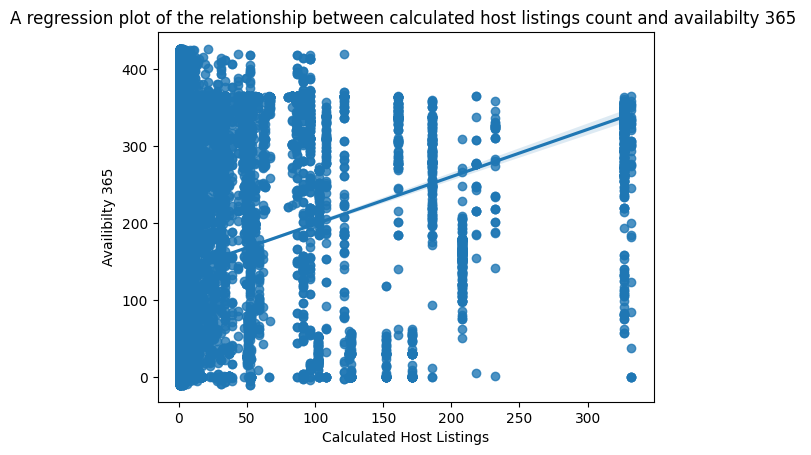

In [52]:
sns.regplot(df,x="calculated host listings count",y="availability 365");
plt.xlabel("Calculated Host Listings");
plt.ylabel("Availibilty 365");
plt.title("A regression plot of the relationship between calculated host listings count and availabilty 365 ")


In [53]:
df["calculated host listings count"].corr(df["availability 365"])

np.float64(0.1359971471570339)